In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

from Autograd import Tensor
from Model import Linear,Sequential,Layernorm
from Activation import ReLU
from Loss import cross_entropy_one_hot
from Training import training
from Data import testing_data_processing, training_data_processing
from Testing import classification_accuracy
from Optimiser import SGD

Using the original Layer Norm paper linked below as a basis, I implemented the layer norm. Emperically it has been shown that layer norm can increase speed of convergence during gradient descent.

We perform z-score standardisation across the feature dimensions on the output of a linear layer. So each sample has its own respective mean and standard deviation for each layer norm applied. As defined by the paper we use the population standard deviation.
After this, we apply an affine transformation on the standardised outputs, where the parameters for this are leared through gradient descent.

The original paper focused on its use in RNNs, however, I have used it in my MLP implementation. The layer norm is also used in the transformer architecture from 'Attention is all you need'.


https://arxiv.org/pdf/1607.06450

In [2]:
normalisedfeatures,price_range,columnmean,columnstd,nofeatures,noclasses,nosamples=training_data_processing()

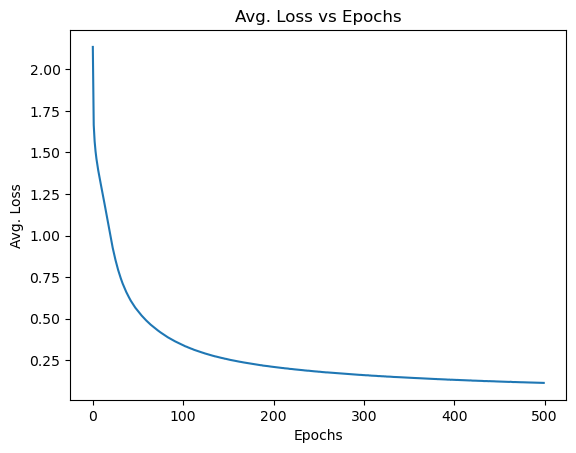

0.1128366583634668


In [3]:
GD_model=Sequential([Linear(nofeatures,10), ReLU(),Linear(10,noclasses)])
loss_fn=cross_entropy_one_hot
optimiser=SGD(GD_model.parameters(),0.005)
GD_losses=training(normalisedfeatures,GD_model,price_range,loss_fn,500,optimiser,32)
plt.plot(GD_losses)
plt.xlabel("Epochs")
plt.ylabel("Avg. Loss")
plt.title("Avg. Loss vs Epochs")
plt.show()
print(GD_losses[-1])

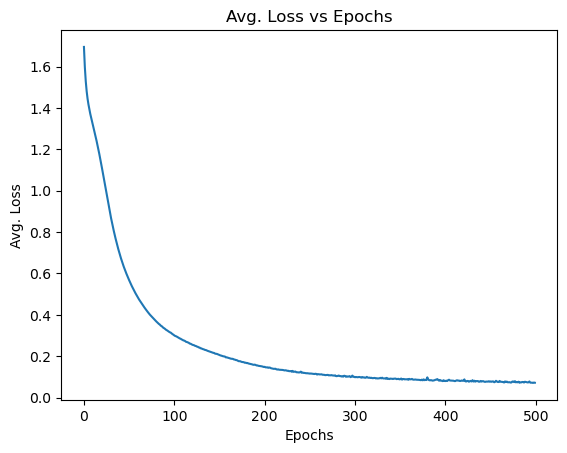

0.0715455343407684


In [12]:
layernorm_model=Sequential([Linear(nofeatures,10), Layernorm(10),ReLU(),Linear(10,noclasses)])
loss_fn=cross_entropy_one_hot
optimiser2=SGD(layernorm_model.parameters(),0.005)
layernorm_losses=training(normalisedfeatures,layernorm_model,price_range,loss_fn,500,optimiser2,32)
plt.plot(layernorm_losses)
plt.xlabel("Epochs")
plt.ylabel("Avg. Loss")
plt.title("Avg. Loss vs Epochs")
plt.show()
print(layernorm_losses[-1])

We can see from the results that after 500 epochs of 32 batch-size SGD, the loss when using Layer norm is 0.0715 compared to 0.113 without, so we have likely converged faster using the layer norm.

Combining layer norm with other optimisation techniques like momentum or AdaGrad can likely further improve performance of training.

There exists many hypothesis for why layer norm may improve speed of convergence. One such hypothesis is that layer norm keeps the parameter scaling consistent throughout the model, hence the gradients used in SGD remain stable. There is, however, no universally agreed hypothesis.

In [13]:
test_ins,test_out=testing_data_processing(columnmean,columnstd)
GD_test_logits=GD_model.forward_prop(test_ins)
layernorm_test_logits=layernorm_model.forward_prop(test_ins)
GD_test_loss=cross_entropy_one_hot(GD_test_logits,test_out).data
layernorm_test_loss=cross_entropy_one_hot(layernorm_test_logits,test_out).data
GD_test_accuracy=classification_accuracy(GD_test_logits,test_out)
layernorm_test_accuracy=classification_accuracy(layernorm_test_logits,test_out)
print("GD Validation loss:", GD_test_loss)
print("Layernorm Validation loss:", layernorm_test_loss)
print("GD Validation accuracy:", GD_test_accuracy)
print("Layernorm Validation accuracy:", layernorm_test_accuracy)

GD Validation loss: 0.15559056189391346
Layernorm Validation loss: 0.10035866980908283
GD Validation accuracy: 0.9421768707482994
Layernorm Validation accuracy: 0.95578231292517


From the above results we can see that using layernorm generalises better than without. Notably a lower validation loss and a higher classification accuracy.